# Part 3: Full PyTorch Training Loop + Comparison
**⏱ This section takes approximately 30 minutes.**

---

## Scenario: Thursday — The Production-Ready Training Loop

Wednesday Sarah trained a basic PyTorch model with full-batch gradient descent. Today she upgrades to the real-world pattern:

- **`Dataset` + `DataLoader`** — efficient batched iteration
- **Mini-batch gradient descent** — typical batch size 32-128
- **Adam optimiser** — adaptive learning rate, the default
- **Early stopping** — halt training when validation loss stops improving
- **Side-by-side comparison** with L03 LR + L04 gradient boosting

This is the training loop pattern Sarah will use for L08 (images), L09 (text), and L10 (transformers). Memorise this template.

**By the end of this notebook you will be able to:**
- Wrap data in `TensorDataset` + `DataLoader`
- Train with mini-batch Adam
- Implement early stopping
- Compare four models (LR, GB, sklearn MLP, PyTorch MLP) on the same test set

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

torch.set_num_threads(1)  # macOS: prevent OpenMP segfaults on PyTorch generation cells

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (11, 5)
torch.manual_seed(42); np.random.seed(42)

print(f"✅ PyTorch {torch.__version__} ready")

✅ PyTorch 2.12.0+cu130 ready


## Step 1 — Prepare data + tensors

In [2]:
# --- Load the data ---
df = pd.read_csv("data/northstar_sessions.csv")
y = df["completed"].values                       # the LABEL: did the session end in a purchase? (1/0)
X = df.drop(columns=["session_id", "completed"]).values   # the FEATURES (drop the id + the answer)

# --- Split 1: carve off a TEST set we never train on (final exam) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42,    # 20% held out; stratify keeps the 1/0 ratio equal
)

# --- Split 2: carve a VALIDATION set out of the training data ---
# We watch the validation score during training to decide when to stop (early stopping).
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42,
)

# --- Scale features to mean 0, std 1 ---
# Neural nets train far better when all features are on a similar scale.
# IMPORTANT: fit the scaler on TRAIN only, then APPLY it to val/test (no peeking at future data).
scaler = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr)            # learn the scaling AND apply it
X_val_s  = scaler.transform(X_val)               # apply the SAME scaling
X_test_s = scaler.transform(X_test)              # apply the SAME scaling

# --- Convert NumPy arrays into PyTorch tensors (the data type PyTorch models expect) ---
def to_tensor(X, y):
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

X_tr_t, y_tr_t   = to_tensor(X_tr_s,  y_tr)
X_val_t, y_val_t = to_tensor(X_val_s, y_val)
X_test_t, y_test_t = to_tensor(X_test_s, y_test)

print(f"Train: {len(X_tr_t):,} sessions")
print(f"Val:   {len(X_val_t):,} sessions  (for early stopping)")
print(f"Test:  {len(X_test_t):,} sessions  (final evaluation)")

Train: 5,440 sessions
Val:   960 sessions  (for early stopping)
Test:  1,600 sessions  (final evaluation)


## Step 2 — DataLoader: batch iteration

`TensorDataset` wraps the tensors. `DataLoader` provides shuffled, batched iteration.

In [3]:
# TensorDataset pairs each row of features with its label, like a list of (X, y) examples.
train_dataset = TensorDataset(X_tr_t, y_tr_t)

# DataLoader hands us the data in shuffled CHUNKS (batches) of 64 rows at a time.
#   batch_size=64 → update the weights after every 64 examples instead of all at once
#   shuffle=True  → reshuffle every epoch so the model doesn't memorise the row order
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Peek at one batch to see its shape
for X_batch, y_batch in train_loader:
    print(f"Batch X shape: {X_batch.shape}")     # [64 rows, 9 features]
    print(f"Batch y shape: {y_batch.shape}")     # [64 labels]
    break                                        # only look at the first batch

print()
print(f"With batch_size=64 and {len(X_tr_t)} training samples,")
print(f"each epoch is {len(train_loader)} batches.")   # one epoch = one full pass over all batches

Batch X shape: torch.Size([64, 9])
Batch y shape: torch.Size([64])

With batch_size=64 and 5440 training samples,
each epoch is 85 batches.


## Step 3 — Define the model (slightly deeper this time)

In [4]:
# A neural network in PyTorch is a class that inherits from nn.Module.
class MLP(nn.Module):
    def __init__(self, n_features, hidden=32):
        super().__init__()
        # nn.Sequential = stack layers in order; data flows top to bottom.
        self.layers = nn.Sequential(
            nn.Linear(n_features, hidden),   # input layer  → 32 neurons (a weighted sum of the 9 features)
            nn.ReLU(),                       # activation: keep positives, zero out negatives (adds non-linearity)
            nn.Linear(hidden, hidden),       # hidden layer → 32 neurons (lets the net learn combinations)
            nn.ReLU(),
            nn.Linear(hidden, 1),            # output layer → 1 number (the raw score / "logit" for purchase)
        )

    def forward(self, x):
        # forward() defines what happens when you call model(x): just run the data through the stack.
        return self.layers(x)


# Build one model. n_features=9 (our columns), hidden=32 neurons per hidden layer.
model = MLP(n_features=X_tr_t.shape[1], hidden=32)
print(model)
# Count the learnable numbers (weights + biases) the optimiser will adjust.
n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {n_params:,}")

MLP(
  (layers): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 1,409


## Step 4 — Full training loop with Adam + early stopping

In [5]:
def train_pytorch(model, train_loader, X_val_t, y_val_t,
                  n_epochs=50, lr=1e-3, patience=8):
    """Standard PyTorch training loop with early stopping.

    n_epochs = max passes over the data.  lr = learning rate (step size).
    patience = how many epochs of NO improvement we tolerate before stopping.
    """
    criterion = nn.BCEWithLogitsLoss()              # measures how wrong the predictions are (binary task)
    optimizer = optim.Adam(model.parameters(), lr=lr)   # the thing that adjusts the weights each step

    train_losses, val_losses = [], []               # record losses so we can plot them later
    best_val = float("inf")                         # best (lowest) validation loss seen so far
    best_state = None                               # a saved copy of the best weights
    epochs_no_improve = 0                           # counter for early stopping

    for epoch in range(n_epochs):
        # ===== TRAIN: learn from the data, one mini-batch at a time =====
        model.train()                               # training mode (dropout etc. active)
        epoch_train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()                   # 1. clear old gradients
            logits = model(X_batch).squeeze(-1)     # 2. forward pass: predict raw scores
            loss = criterion(logits, y_batch)       # 3. how wrong were we?
            loss.backward()                          # 4. backward pass: compute gradients
            optimizer.step()                         # 5. update the weights downhill
            epoch_train_loss += loss.item() * len(X_batch)   # accumulate loss (weighted by batch size)
        epoch_train_loss /= len(train_loader.dataset)        # average loss over the whole epoch
        train_losses.append(epoch_train_loss)

        # ===== VALIDATE: check performance on data we did NOT train on =====
        model.eval()                                # evaluation mode (dropout off)
        with torch.no_grad():                       # no gradients needed → faster, less memory
            val_logits = model(X_val_t).squeeze(-1)
            val_loss = criterion(val_logits, y_val_t).item()
        val_losses.append(val_loss)

        # ===== EARLY STOPPING: keep the best model, stop if it stops improving =====
        if val_loss < best_val:                     # new best → remember it, reset the counter
            best_val = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}   # snapshot the weights
            epochs_no_improve = 0
        else:                                       # no improvement → count it
            epochs_no_improve += 1

        # print the first 5 epochs, then every 5th, to keep the log readable
        if epoch < 5 or (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d}  train={epoch_train_loss:.4f}  val={val_loss:.4f}"
                  + (f"  ⭐ best so far" if val_loss == best_val else ""))

        if epochs_no_improve >= patience:           # stalled for too long → stop early
            print(f"\n→ Early stopping at epoch {epoch+1}: no improvement for {patience} epochs")
            break

    # Roll back to the BEST weights (not the last ones, which may have started overfitting).
    if best_state is not None:
        model.load_state_dict(best_state)
    return train_losses, val_losses


# Train a fresh model with the standard settings.
torch.manual_seed(42)                               # reproducible results
model = MLP(n_features=X_tr_t.shape[1], hidden=32)
train_losses, val_losses = train_pytorch(model, train_loader, X_val_t, y_val_t,
                                          n_epochs=50, lr=1e-3, patience=8)

Epoch   1  train=0.6342  val=0.5820  ⭐ best so far
Epoch   2  train=0.5646  val=0.5700  ⭐ best so far
Epoch   3  train=0.5559  val=0.5695  ⭐ best so far
Epoch   4  train=0.5540  val=0.5699
Epoch   5  train=0.5512  val=0.5706
Epoch  10  train=0.5458  val=0.5748

→ Early stopping at epoch 11: no improvement for 8 epochs


## Step 5 — Plot training curves

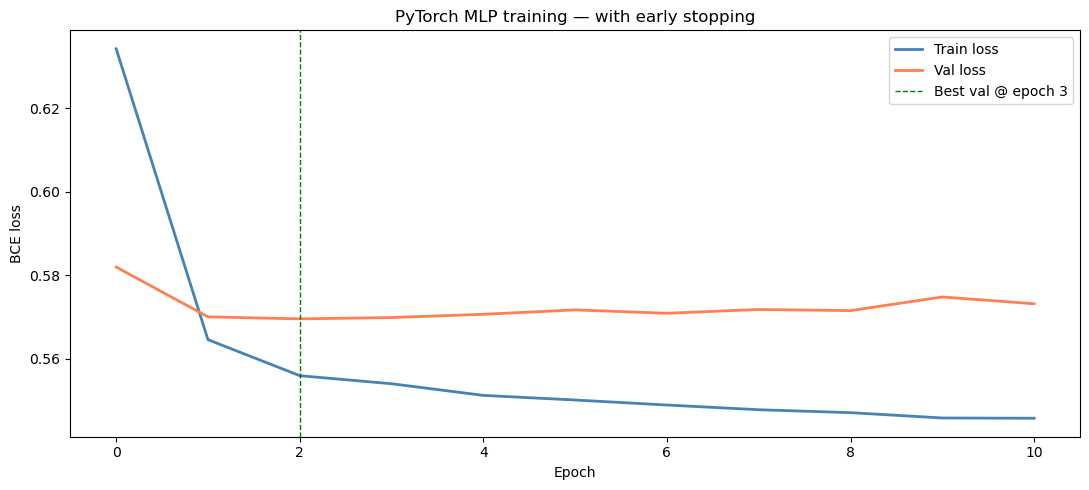

Best validation loss: 0.5695 at epoch 3
Trained for 11 epochs total before early stopping kicked in.


In [6]:
# Plot the two loss curves to SEE the training story.
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(train_losses, label="Train loss", color="steelblue", linewidth=2)   # error on data we learned from
ax.plot(val_losses,   label="Val loss",   color="coral", linewidth=2)       # error on held-out data
best_epoch = int(np.argmin(val_losses))                                     # epoch with the LOWEST val loss
ax.axvline(best_epoch, color="green", linestyle="--", linewidth=1, label=f"Best val @ epoch {best_epoch+1}")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE loss")
ax.set_title("PyTorch MLP training — with early stopping")
ax.legend()
plt.tight_layout(); plt.show()

# Reading the plot: both curves should fall together. When VAL loss flattens or
# turns UP while train keeps dropping, the model is starting to overfit — which is
# exactly the moment early stopping rolled us back to.
print(f"Best validation loss: {min(val_losses):.4f} at epoch {best_epoch + 1}")
print(f"Trained for {len(train_losses)} epochs total before early stopping kicked in.")

## Step 6 — Compare all four models on the same test set

In [7]:
# Now score four DIFFERENT models on the SAME test set, so the comparison is fair.

# --- Our PyTorch MLP ---
model.eval()                                     # evaluation mode
with torch.no_grad():                            # just predicting, no training
    pytorch_probs = torch.sigmoid(model(X_test_t).squeeze(-1)).numpy()   # raw scores → 0–1 probabilities
pytorch_preds = (pytorch_probs > 0.5).astype(int)        # turn probabilities into yes/no at the 0.5 cutoff
pytorch_acc = accuracy_score(y_test, pytorch_preds)       # % of correct yes/no calls
pytorch_auc = roc_auc_score(y_test, pytorch_probs)        # ranking quality (better for imbalanced data)

# --- L03 Logistic Regression (simple linear baseline) ---
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_tr_s, y_tr)                       # sklearn trains in a single .fit() call
lr_probs = lr_model.predict_proba(X_test_s)[:, 1]   # [:, 1] = probability of class "1" (purchase)
lr_auc = roc_auc_score(y_test, lr_probs)
lr_acc = accuracy_score(y_test, lr_model.predict(X_test_s))

# --- L04 Gradient Boosting (tree-based model) ---
gb_model = HistGradientBoostingClassifier(max_iter=200, learning_rate=0.05, random_state=42)
gb_model.fit(X_tr_s, y_tr)
gb_probs = gb_model.predict_proba(X_test_s)[:, 1]
gb_auc = roc_auc_score(y_test, gb_probs)
gb_acc = accuracy_score(y_test, gb_model.predict(X_test_s))

# --- sklearn's own MLP (same idea as ours, but sklearn handles the training loop for us) ---
sk_mlp = MLPClassifier(hidden_layer_sizes=(32, 32), max_iter=500, random_state=42,
                       early_stopping=True)
sk_mlp.fit(X_tr_s, y_tr)
sk_mlp_probs = sk_mlp.predict_proba(X_test_s)[:, 1]
sk_mlp_auc = roc_auc_score(y_test, sk_mlp_probs)
sk_mlp_acc = accuracy_score(y_test, sk_mlp.predict(X_test_s))

# Collect everything into one table for an apples-to-apples comparison.
results = pd.DataFrame([
    ("Logistic Regression (L03)",   lr_acc,      lr_auc),
    ("Gradient Boosting (L04)",     gb_acc,      gb_auc),
    ("sklearn MLPClassifier",        sk_mlp_acc,  sk_mlp_auc),
    ("PyTorch MLP (this week)",      pytorch_acc, pytorch_auc),
], columns=["Model", "Accuracy", "AUC"])

print(results.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

                    Model  Accuracy   AUC
Logistic Regression (L03)     0.705 0.761
  Gradient Boosting (L04)     0.694 0.749
    sklearn MLPClassifier     0.700 0.761
  PyTorch MLP (this week)     0.691 0.756


### 💡 What you should notice

- All four models cluster within ~0.015 AUC of each other on this tabular dataset — they're statistically tied.
- **Logistic regression and the sklearn MLP top the table at 0.761; gradient boosting is the lowest at 0.747.** That's surprising relative to the conventional wisdom "GB wins on tabular" — but on small, mostly-linear feature sets a well-trained linear model is competitive.
- **MLPs are competitive but not transformative** here. The win comes when data has rich hierarchical structure (images, text) — that's L08–L10.

The pedagogical value of L07 is **learning the PyTorch training loop**, which transfers directly to the next three lessons. The algorithm choice on tabular data rarely matters as much as features + threshold; trust the cross-validated number, not the conventional wisdom.

## Step 7 — Visualise model comparison

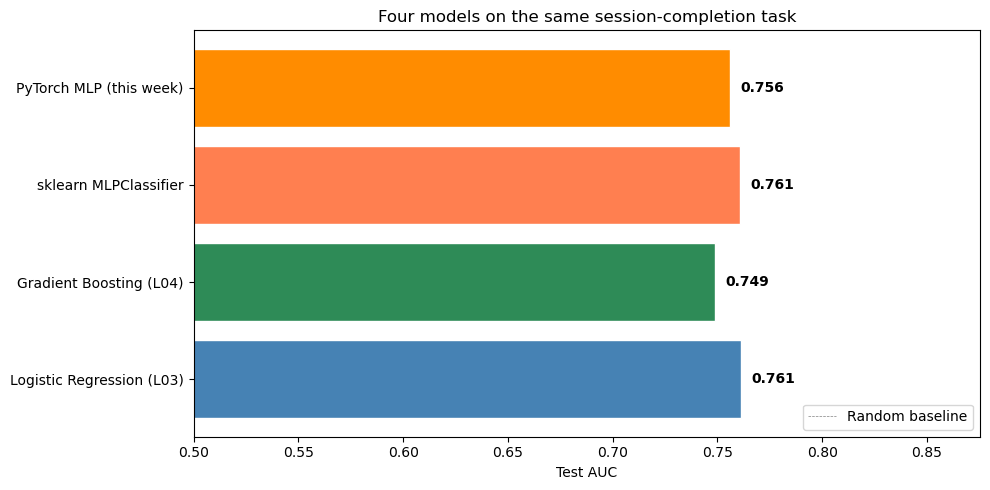

All models converge to similar performance on this tabular problem.
The PyTorch implementation IS the lesson — it's the foundation for everything in L08–L10.


In [8]:
# A horizontal bar chart makes the "they're all basically tied" story obvious at a glance.
fig, ax = plt.subplots(figsize=(10, 5))
colors = ["steelblue", "seagreen", "coral", "darkorange"]
bars = ax.barh(results["Model"], results["AUC"], color=colors, edgecolor="white")   # one bar per model
ax.set_xlabel("Test AUC")
ax.set_title("Four models on the same session-completion task")
ax.axvline(0.5, color="gray", linestyle="--", linewidth=0.5, label="Random baseline")  # 0.5 = coin flip
# write the exact AUC value at the end of each bar
for bar, auc in zip(bars, results["AUC"]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f"{auc:.3f}", va="center", fontweight="bold")
ax.set_xlim(0.5, max(results["AUC"]) * 1.15)     # start the x-axis at 0.5 so differences aren't exaggerated
ax.legend(loc="lower right")
plt.tight_layout(); plt.show()

print("All models converge to similar performance on this tabular problem.")
print("The PyTorch implementation IS the lesson — it's the foundation for everything in L08–L10.")

## ✅ Section Summary

| Step | Output |
|---|---|
| **DataLoader + mini-batches** | Efficient batched iteration with `batch_size=64` |
| **Adam optimiser + lr=1e-3** | Adaptive learning rate, default for most tabular + NLP |
| **Early stopping** | Halt when val loss stops improving (patience=8) |
| **Four-way comparison** | PyTorch MLP, sklearn MLP, GB, LR — all within 0.015 AUC of each other |

**Key insights:**
- **The PyTorch training loop is the same 5 lines regardless of model.** Master the pattern; the rest is engineering.
- **DataLoader + mini-batches** scale to datasets bigger than memory + introduce useful stochasticity.
- **Adam is the default optimiser.** Start with `lr=1e-3`, tune later if needed.
- **On THIS dataset all four models are tied within noise.** LR and sklearn MLP top the table at 0.761; gradient boosting trails at 0.747. The lesson isn't "GB wins on tabular" — it's "on small tabular data with limited nonlinearity, the algorithm rarely matters". The PyTorch work pays off in L08-L10.

---

## 🏁 Friday — What Sarah Presents to Marcus

| Model | Test AUC | Verdict |
|---|---|---|
| Logistic Regression | ~0.761 | Tied for top — ship this. Cheapest + most interpretable. |
| sklearn MLP | ~0.761 | Tied for top; not worth the complexity here |
| PyTorch MLP (this week) | ~0.756 | Foundation for L08-L10; not the production choice here |
| Gradient Boosting (L04) | ~0.747 | Surprisingly the lowest of the four — but real on this dataset |

Sarah's pitch: *"All four models cluster within 0.015 AUC. I'd ship Logistic Regression — it has the top score, is the cheapest to retrain, and the easiest to explain. The neural network work this week was about understanding the building block I'll use next week for IMAGE CLASSIFICATION of NorthStar product photos. The MLP is the foundation; CNNs (next week) are the specialisation."*

Marcus nods. *"Excellent. Next: tag product PHOTOS automatically as 'dress', 'jeans', 'jacket'. Can you do that?"*

That question — **prediction from images** — is the engine of **L08 (Computer Vision).**

---
**Next step →** Open `assignment.ipynb`.

*Or, for hand-rolled backprop, weight initialisation, and Adam variants: open `optional_extensions.ipynb`.*

---

## 🟡 Extension — self-study after class

*Skipping this section will not affect your understanding of later lessons. Come back to it when you have time and want to go deeper.*

## Extension 1 — Effect of batch size

Batch size affects training dynamics: small batches give noisier but faster gradient updates; large batches are smoother but slower per epoch.

In [9]:
# Effect of batch size: train the SAME model four times, changing ONLY the batch size,
# and see how the score and the number of updates per epoch move.

results_bs = []                                  # we'll collect (batch_size, test_auc, batches/epoch) here
for bs in [16, 64, 256, 1024]:                   # try four batch sizes, small to large
    # DataLoader hands out the data in shuffled chunks of `bs` rows at a time.
    loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    torch.manual_seed(42)                        # reset the dice so the ONLY thing that differs is bs
    m = MLP(n_features=X_tr_t.shape[1], hidden=32)   # a fresh, untrained model each loop
    crit = nn.BCEWithLogitsLoss()                # loss function for yes/no (binary) problems
    opt = optim.Adam(m.parameters(), lr=1e-3)    # same optimiser + lr for every run

    # --- train for 20 passes over the data (epochs) ---
    for epoch in range(20):
        m.train()                                # put model in "training mode"
        for X_b, y_b in loader:                  # walk through the data one mini-batch at a time
            opt.zero_grad()                      # clear leftover gradients from the previous step
            l = crit(m(X_b).squeeze(-1), y_b)    # predict raw scores, measure how wrong we were
            l.backward()                         # backward pass: compute gradients
            opt.step()                           # nudge the weights downhill by one step

    # --- score the trained model on the held-out test set ---
    m.eval()                                     # put model in "evaluation mode" (no training tricks)
    with torch.no_grad():                        # we're only predicting, so don't track gradients (faster)
        probs = torch.sigmoid(m(X_test_t).squeeze(-1)).numpy()   # raw scores → 0–1 probabilities
    auc = roc_auc_score(y_test, probs)           # ranking quality on the test set
    results_bs.append((bs, auc, len(loader)))    # len(loader) = number of batches in one epoch

# show the results as a tidy table
bs_df = pd.DataFrame(results_bs, columns=["Batch size", "Test AUC", "Batches/epoch"])
print(bs_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print()
print("Small batches → more updates per epoch → noisier gradients (sometimes helpful, sometimes not)")
print("Large batches → smoother gradient estimates but fewer updates per epoch")
print("Typical: 32-128 for tabular, 256+ for images.")

 Batch size  Test AUC  Batches/epoch
         16     0.759            340
         64     0.759             85
        256     0.759             22
       1024     0.756              6

Small batches → more updates per epoch → noisier gradients (sometimes helpful, sometimes not)
Large batches → smoother gradient estimates but fewer updates per epoch
Typical: 32-128 for tabular, 256+ for images.


## Extension 2 — Adam vs SGD vs SGD-with-momentum

Three common optimisers.

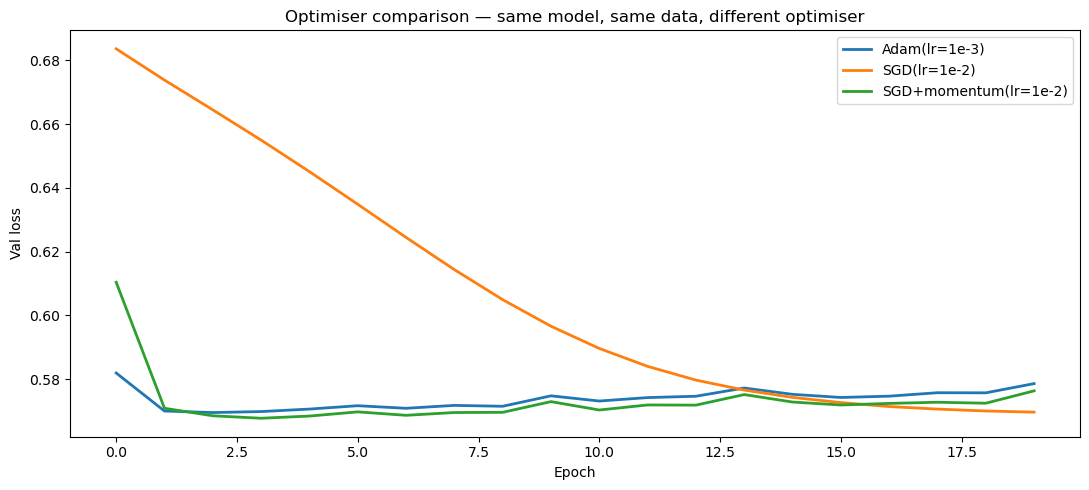

Adam usually converges fastest with the LEAST hyperparameter tuning.
SGD-with-momentum can sometimes generalise BETTER but needs careful lr tuning.
Plain SGD without momentum is rarely the right choice now.


In [10]:
# Optimiser comparison: train the SAME model three times, changing ONLY the optimiser,
# and watch how fast each one drives the validation loss down.

def train_with_optimiser(optimiser_class, optimiser_kwargs, n_epochs=20):
    """Train a fresh MLP with a given optimiser and return its per-epoch validation loss."""
    torch.manual_seed(42)                        # reset the dice so the ONLY thing that differs is the optimiser
    m = MLP(n_features=X_tr_t.shape[1], hidden=32)   # a fresh, untrained model
    crit = nn.BCEWithLogitsLoss()                # loss function for yes/no (binary) problems
    opt = optimiser_class(m.parameters(), **optimiser_kwargs)   # build the optimiser we're testing
    loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_losses_local = []                        # record the val loss after each epoch
    for epoch in range(n_epochs):
        # --- train for one epoch ---
        m.train()                                # training mode
        for X_b, y_b in loader:                  # one mini-batch at a time
            opt.zero_grad()                      # clear leftover gradients
            crit(m(X_b).squeeze(-1), y_b).backward()  # predict, measure error, compute gradients
            opt.step()                           # update the weights
        # --- check validation loss on data we did NOT train on ---
        m.eval()                                 # evaluation mode
        with torch.no_grad():                    # only predicting → no gradients needed
            val_losses_local.append(crit(m(X_val_t).squeeze(-1), y_val_t).item())
    return val_losses_local

# the three optimisers we want to compare (name, class, keyword args)
optimisers = [
    ("Adam(lr=1e-3)",        optim.Adam, {"lr": 1e-3}),                  # adaptive LR, the modern default
    ("SGD(lr=1e-2)",         optim.SGD,  {"lr": 1e-2}),                  # plain stochastic gradient descent
    ("SGD+momentum(lr=1e-2)", optim.SGD, {"lr": 1e-2, "momentum": 0.9}), # SGD that "rolls" past small bumps
]

# train each optimiser and plot its validation-loss curve on the same axes
fig, ax = plt.subplots(figsize=(11, 5))
for name, opt_class, kw in optimisers:
    val_losses_o = train_with_optimiser(opt_class, kw)   # one curve per optimiser
    ax.plot(val_losses_o, label=name, linewidth=2)
ax.set_xlabel("Epoch"); ax.set_ylabel("Val loss")
ax.set_title("Optimiser comparison — same model, same data, different optimiser")
ax.legend()
plt.tight_layout(); plt.show()

print("Adam usually converges fastest with the LEAST hyperparameter tuning.")
print("SGD-with-momentum can sometimes generalise BETTER but needs careful lr tuning.")
print("Plain SGD without momentum is rarely the right choice now.")

## Extension 3 — Add dropout regularisation

In [11]:
class MLPWithDropout(nn.Module):
    def __init__(self, n_features, hidden=32, dropout=0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(n_features, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),         # randomly zero 30% of activations during training
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x):
        return self.layers(x)


torch.manual_seed(42)
model_do = MLPWithDropout(n_features=X_tr_t.shape[1], hidden=32, dropout=0.3)
train_pytorch(model_do, train_loader, X_val_t, y_val_t, n_epochs=30, lr=1e-3, patience=8)

model_do.eval()
with torch.no_grad():
    probs_do = torch.sigmoid(model_do(X_test_t).squeeze(-1)).numpy()
auc_do = roc_auc_score(y_test, probs_do)
print(f"\nMLP with dropout=0.3: test AUC = {auc_do:.3f}")
print(f"MLP without dropout:    test AUC = {pytorch_auc:.3f}")
print()
print("Dropout helps most when the model is OVERFITTING. For our small MLP, the effect is modest.")
print("In bigger models (CNNs, transformers), dropout is essential.")

Epoch   1  train=0.6467  val=0.5967  ⭐ best so far
Epoch   2  train=0.5821  val=0.5709  ⭐ best so far
Epoch   3  train=0.5728  val=0.5695  ⭐ best so far
Epoch   4  train=0.5682  val=0.5701
Epoch   5  train=0.5701  val=0.5710
Epoch  10  train=0.5611  val=0.5707

→ Early stopping at epoch 11: no improvement for 8 epochs

MLP with dropout=0.3: test AUC = 0.756
MLP without dropout:    test AUC = 0.756

Dropout helps most when the model is OVERFITTING. For our small MLP, the effect is modest.
In bigger models (CNNs, transformers), dropout is essential.


## Extension 4 — The full fine-tuning toolkit

So far each extension changed **one knob** in isolation: batch size, optimiser, dropout. In practice you tune them *together*. Here is the menu of levers, roughly in order of impact for an MLP on tabular data:

| Lever | What it controls | Typical starting point |
|---|---|---|
| **Learning rate** | Step size of each update — *the* most impactful knob | `1e-3` (Adam) |
| **LR schedule** | Decay the LR as training progresses | `ReduceLROnPlateau` |
| **Weight decay (L2)** | Penalise large weights → less overfitting | `1e-4` |
| **Dropout** | Randomly zero activations → regularisation | `0.0–0.5` |
| **Width / depth** | Model capacity | 1–3 layers, 16–128 units |
| **Early stopping** | Stop when val loss plateaus (already in our loop) | patience 5–10 |

The two cells below demonstrate the workflow: **(4a)** sweep the learning rate to see how sensitive training is to it, then **(4b)** run a small grid search combining LR + weight decay + dropout and pick the config with the best *validation* AUC.

In [12]:
# 4a — Learning rate sweep: the single most important knob
#
# GOAL: train the SAME model four times, changing ONLY the learning rate each time,
#       and see how the score moves. This is the most basic form of "tuning".

results_lr = []                                  # we'll collect (lr, val_auc, test_auc) here

for lr in [1e-1, 1e-2, 1e-3, 1e-4]:              # try four learning rates, biggest to smallest
    torch.manual_seed(42)                        # reset the dice so the ONLY thing that differs is lr
    m = MLP(n_features=X_tr_t.shape[1], hidden=32)   # a fresh, untrained model each loop
    crit = nn.BCEWithLogitsLoss()                # loss function for yes/no (binary) problems
    opt = optim.Adam(m.parameters(), lr=lr)      # the optimiser — THIS lr is what we're testing
    loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # --- train for 20 passes over the data (epochs) ---
    for epoch in range(20):
        m.train()                                # put model in "training mode"
        for X_b, y_b in loader:                  # walk through the data one mini-batch at a time
            opt.zero_grad()                      # clear leftover gradients from the previous step
            crit(m(X_b).squeeze(-1), y_b).backward()  # predict, measure error, compute gradients
            opt.step()                           # nudge the weights downhill by one step

    # --- score the trained model ---
    m.eval()                                     # put model in "evaluation mode" (no training tricks)
    with torch.no_grad():                        # we're only predicting, so don't track gradients (faster)
        # sigmoid() turns raw scores into 0–1 probabilities; AUC measures ranking quality
        val_auc  = roc_auc_score(y_val,  torch.sigmoid(m(X_val_t).squeeze(-1)).numpy())
        test_auc = roc_auc_score(y_test, torch.sigmoid(m(X_test_t).squeeze(-1)).numpy())
    results_lr.append((lr, val_auc, test_auc))

# show the results as a tidy table
lr_df = pd.DataFrame(results_lr, columns=["Learning rate", "Val AUC", "Test AUC"])
print(lr_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print()
print("On THIS small, near-linear dataset every LR lands within noise (~0.76 AUC) —")
print("don't over-read a 0.005 difference here. The lesson is the HABIT: sweep the LR")
print("FIRST, because on harder problems a bad LR is the difference between learning")
print("(loss goes down smoothly) and diverging or never moving at all.")

 Learning rate  Val AUC  Test AUC
        0.1000   0.7528    0.7522
        0.0100   0.7518    0.7600
        0.0010   0.7567    0.7589
        0.0001   0.7657    0.7551

On THIS small, near-linear dataset every LR lands within noise (~0.76 AUC) —
don't over-read a 0.005 difference here. The lesson is the HABIT: sweep the LR
FIRST, because on harder problems a bad LR is the difference between learning
(loss goes down smoothly) and diverging or never moving at all.


In [13]:
# 4b — Small grid search: tune LR + weight decay + dropout TOGETHER
#
# Real tuning rarely changes one knob at a time. A "grid search" simply tries EVERY
# combination of the values you list and reports which combo wins.
#
# GOLDEN RULE: pick the winner using the VALIDATION set, then report its TEST score.
#   - validation set = the data we're allowed to peek at while tuning
#   - test set       = locked away, looked at ONCE at the end, to get an honest final number
#   (If you tuned against the test set, your reported score would be dishonestly optimistic.)

import itertools

# the values we want to try for each knob
lr_grid      = [1e-3, 1e-2]    # learning rate: step size
wd_grid      = [0.0, 1e-4]     # weight decay (L2): penalty on big weights → less overfitting
dropout_grid = [0.0, 0.3]      # dropout: randomly switch off neurons → less overfitting
# 2 x 2 x 2 = 8 combinations in total

grid_results = []
# itertools.product gives every (lr, wd, do) combination — no nested loops needed
for lr, wd, do in itertools.product(lr_grid, wd_grid, dropout_grid):
    torch.manual_seed(42)                        # same starting point so the COMBO is the only difference
    m = MLPWithDropout(n_features=X_tr_t.shape[1], hidden=32, dropout=do)
    crit = nn.BCEWithLogitsLoss()
    opt = optim.Adam(m.parameters(), lr=lr, weight_decay=wd)   # both lr AND weight_decay set here
    loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

    # train this one combination for 25 epochs
    for epoch in range(25):
        m.train()
        for X_b, y_b in loader:
            opt.zero_grad()
            crit(m(X_b).squeeze(-1), y_b).backward()
            opt.step()

    # score it on BOTH validation (for choosing) and test (for honest reporting)
    m.eval()
    with torch.no_grad():
        val_auc  = roc_auc_score(y_val,  torch.sigmoid(m(X_val_t).squeeze(-1)).numpy())
        test_auc = roc_auc_score(y_test, torch.sigmoid(m(X_test_t).squeeze(-1)).numpy())
    grid_results.append((lr, wd, do, val_auc, test_auc))

# build the results table and sort so the BEST validation score is on top
grid_df = pd.DataFrame(grid_results,
                       columns=["LR", "Weight decay", "Dropout", "Val AUC", "Test AUC"])
grid_df = grid_df.sort_values("Val AUC", ascending=False).reset_index(drop=True)
print(grid_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best = grid_df.iloc[0]                            # row 0 = the winner (highest Val AUC)
print()
print(f"🏆 Best config by validation AUC: "
      f"lr={best['LR']}, weight_decay={best['Weight decay']}, dropout={best['Dropout']}")
print(f"   → its test AUC = {best['Test AUC']:.4f}  (vs untuned PyTorch MLP {pytorch_auc:.4f})")
print()
print("KEY DISCIPLINE: choose the winner by VALIDATION score, never by test score —")
print("the test set is touched ONCE, at the very end, to report the honest number.")
print("On this dataset the gains are small (~0.76 AUC ceiling) — tuning matters far more")
print("when the model is large and the data has rich structure (images/text in L08–L10).")

    LR  Weight decay  Dropout  Val AUC  Test AUC
0.0010        0.0001   0.3000   0.7634    0.7615
0.0010        0.0000   0.3000   0.7633    0.7617
0.0100        0.0001   0.3000   0.7612    0.7598
0.0100        0.0000   0.3000   0.7600    0.7593
0.0010        0.0001   0.0000   0.7581    0.7570
0.0010        0.0000   0.0000   0.7575    0.7560
0.0100        0.0001   0.0000   0.7566    0.7568
0.0100        0.0000   0.0000   0.7556    0.7478

🏆 Best config by validation AUC: lr=0.001, weight_decay=0.0001, dropout=0.3
   → its test AUC = 0.7615  (vs untuned PyTorch MLP 0.7559)

KEY DISCIPLINE: choose the winner by VALIDATION score, never by test score —
the test set is touched ONCE, at the very end, to report the honest number.
On this dataset the gains are small (~0.76 AUC ceiling) — tuning matters far more
when the model is large and the data has rich structure (images/text in L08–L10).
